# P1: Repaso de Procesamiento Digital de Señales

**Notación.**

- $x_c(t)$: señal continua en el tiempo (segundos).
- $x[n]$: señal discreta, obtenida por muestreo a frecuencia $f_s$.
- $X[k]$: DFT de un bloque de $N$ muestras de $x[n]$.
- $X[k, t]$: STFT, con $k$ índice de bin frecuencial y $t$ índice de frame.

**Objetivos del notebook.**
1. Verificar numéricamente el cálculo de $L$ y $N_{\text{FFT}}$ del ejercicio 1.
2. Sintetizar las tres señales del ejercicio 2 y reproducirlas.
3. Analizar el espectrograma de una señal no estacionaria.
4. Decodificar una secuencia DTMF.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from IPython.display import Audio, display
plt.rcParams['figure.figsize'] = (10, 4) #Es para settear tamaños de plots
np.set_printoptions(precision=4, suppress=True)

## Ejercicio 3(a)

Sea $x_c(t) = \cos(2\pi f_1 t) + \cos(2\pi f_2 t)$ con $f_1 = 100$ Hz, $f_2 = 200$ Hz, muestreada a $f_s = 500$ Hz.

En el ejercicio 1 se argumentó que para discriminar los dos cosenos: $L_{\text{min}}=\frac{f_s}{f_2-f_1}$. Esto da $L \geq$ <mark>5</mark>.
$N_{\text{FFT}}$ debe ser al menos $L$ y una potencia de $2$ resulta conveniente.

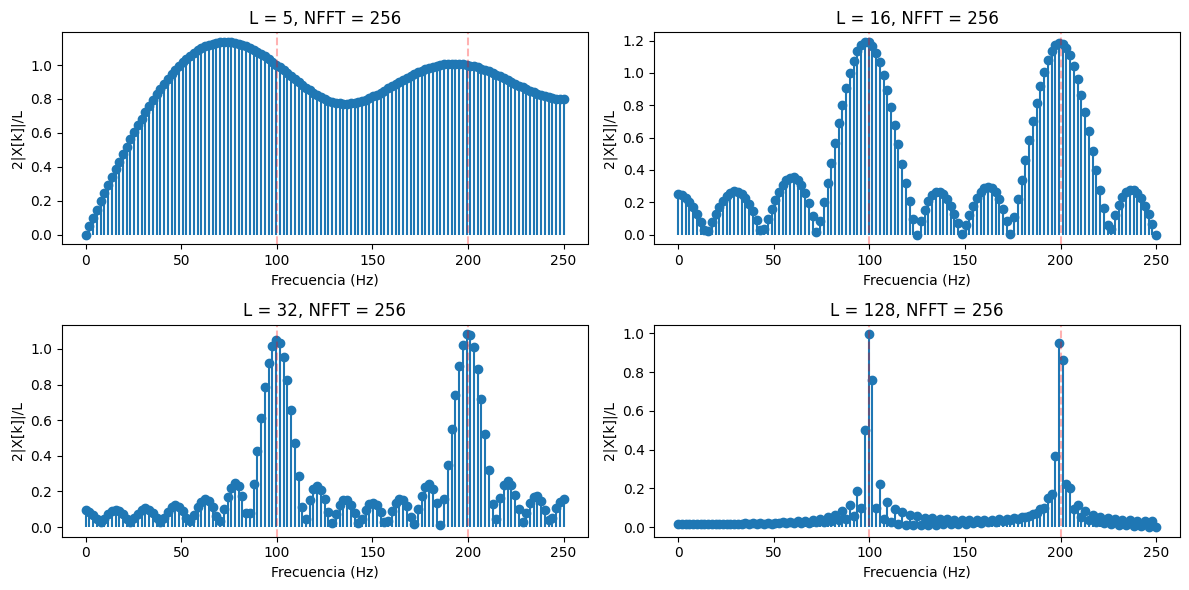

In [6]:
fs = 500
f1, f2 = 100, 200
# Probamos varios L para ver el efecto
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, L in zip(axes.flat, [5, 16, 32, 128]): ### <-- COMPLETAR
    n = np.arange(L)
    x = np.cos(2*np.pi*f1*n/fs) + np.cos(2*np.pi*f2*n/fs) ### <-- COMPLETAR
    NFFT = 256 # Probemos con esta cantidad de puntos
    X = np.fft.rfft(x, n=NFFT)
    freqs = np.fft.rfftfreq(NFFT, 1/fs) # nos quedamos con la mitad no redundante del espectro
    ax.stem(freqs, np.abs(X)/L*2, basefmt=' ') # nos independizamos de la cantidad de muestras
    ax.set_title(f'L = {L}, NFFT = {NFFT}')
    ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('2|X[k]|/L') # la amplitud estimada
    ax.axvline(f1, color='r', alpha=0.3, ls='--')
    ax.axvline(f2, color='r', alpha=0.3, ls='--')
plt.tight_layout(); plt.show()

**Observación.** Para $L =$ <mark>COMPLETAR</mark> los dos lóbulos se alcanzan a separar (apenas).
Para $L =$ <mark>COMPLETAR</mark> se distinguen claramente. Para $L =$ <mark>COMPLETAR</mark> en adelante, las dos líneas
espectrales son perfectamente identificables.

### Efecto de la ventana de Hanning

La ventana de Hanning tiene un lóbulo principal aproximadamente del doble de ancho
que la rectangular, pero lóbulos laterales mucho más bajos. Para leer correctamente
las amplitudes $A$ y $B$ del espectro, se necesita resolver el segundo pico aunque
sea más ancho.

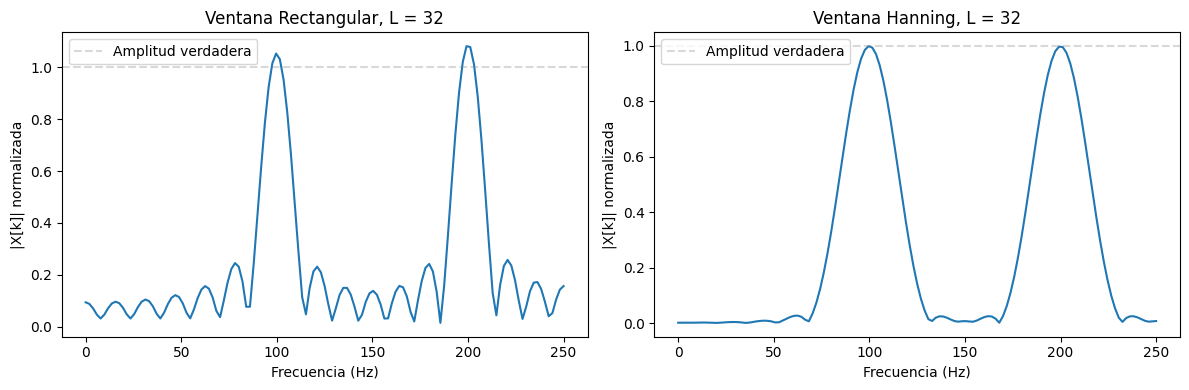

In [7]:
L = 32
n = np.arange(L)
x = np.cos(2*np.pi*f1*n/fs) + np.cos(2*np.pi*f2*n/fs)
w_rect = np.ones(L)
w_hann = np.hanning(L)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, w, name in zip(axes, [w_rect, w_hann], ['Rectangular', 'Hanning']):
    NFFT = 256
    X = np.fft.rfft(x * w, n=NFFT)
    # Normalizamos por la suma de la ventana para que la amplitud sea correcta
    X_norm = np.abs(X) / w.sum() * 2
    freqs = np.fft.rfftfreq(NFFT, 1/fs)
    ax.plot(freqs, X_norm)
    ax.set_title(f'Ventana {name}, L = {L}')
    ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('|X[k]| normalizada')
    ax.axhline(1.0, color='gray', alpha=0.3, ls='--', label='Amplitud verdadera')
    ax.legend()
plt.tight_layout(); plt.show()

**Explicación:** la ventana rectangular permite distinguir mejor dos frecuencias cercanas porque tiene un lóbulo principal más angosto. Sin embargo, sus lóbulos laterales son altos, por lo que produce más fuga espectral. En consecuencia, aunque la normalización por la suma de la ventana corrige la ganancia promedio, las amplitudes medidas en el espectro no coinciden necesariamente con las amplitudes reales de los cosenos. Esto ocurre especialmente cuando las frecuencias no caen exactamente sobre bins de la transformada discreta de Fourier o cuando los dos tonos están suficientemente cerca como para contaminarse entre sí. La ventana de Hanning reduce esa fuga espectral, pero ensancha los picos, por lo que puede dificultar en general la resolución de frecuencias cercanas.

## Ejercicio 3(b)

Acá validamos lo obtenido en el ejercicio 2. Generamos las tres señales y las reproducimos. La idea es escuchar la diferencia entre
$F_0$ matemático y pitch percibido.

In [26]:
fs_audio = 8000
duracion = 0.5
t = np.arange(0, int(duracion*fs_audio))/fs_audio

casos = [
    ('(a) f1=220, f2=440, A=1, B=1',  220, 440, 1.0, 1.0),
    ('(b) f1=220, f2=660, A=2, B=1',  220, 660, 2.0, 1.0),
    ('(c) f1=660, f2=880, A=1, B=0.1', 660, 880, 1.0, 0.1),
]
for nombre, f1, f2, A, B in casos:
    x = A*np.cos(2*np.pi*f1*t) + B*np.cos(2*np.pi*f2*t)
    x = 0.3 * x / np.max(np.abs(x)) # reescalamos la señal para que no sature
    print(nombre)
    print(f'   T0 matematico = {1000/np.gcd(f1, f2):.2f} ms, F0 = {np.gcd(f1, f2)} Hz') ### <-- COMPLETAR
    display(Audio(x, rate=fs_audio))

(a) f1=220, f2=440, A=1, B=1
   T0 matematico = 4.55 ms, F0 = 220 Hz


(b) f1=220, f2=660, A=2, B=1
   T0 matematico = 4.55 ms, F0 = 220 Hz


(c) f1=660, f2=880, A=1, B=0.1
   T0 matematico = 4.55 ms, F0 = 220 Hz


**Conclusión.** <mark>COMPLETAR</mark>.

**Una forma de ver como se comportan las funciones:**

In [17]:
import matplotlib.pyplot as plt plt.plot?

Signature:
plt.plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs,
) -> 'list[Line2D]'
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yie

## Ejercicio 4. Espectrograma de una señal no estacionaria

Generamos una señal sintética con frecuencias variables en el tiempo y analizamos
con STFT. Esto introduce la herramienta principal que usaremos durante todo el curso.

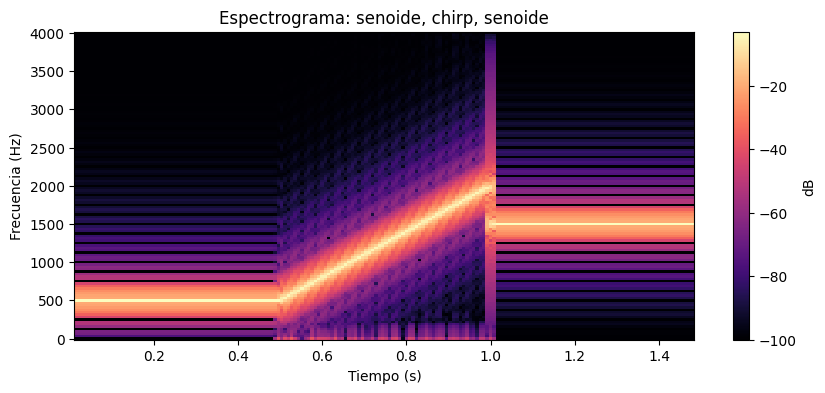

In [35]:
# Senal sintetica con tres tramos de distinta frecuencia
fs = 8000
duracion_total = 1.5
t = np.arange(int(fs * duracion_total)) / fs
y = np.zeros_like(t)
# Tramo 1: usá un coseno
mask = t < 0.5
y[mask] = np.cos(2*np.pi*500*t[mask]) ### Ojo, acá es necesario poner la máscara.
# Tramo 2: usá chirp lineal 
mask = (t >= 0.5) & (t < 1.0)
#DOCUMENTACIÓN: import scipy.signal as sig sig.chirp?
y[mask] = sig.chirp(t[mask]-0.5, f0=500, t1=0.5, f1=2000) ###
# Tramo 3: usá otro coseno
mask = t >= 1.0
y[mask] = np.cos(2*np.pi*1500*t[mask]) ### <-- COMPLETAR

display(Audio(y, rate=fs))

# Espectrograma
f, t_stft, S = sig.spectrogram(y, fs=fs, nperseg=256, noverlap=192, scaling='spectrum')
plt.pcolormesh(t_stft, f, 10*np.log10(S + 1e-10), shading='auto', cmap='magma')
plt.ylabel('Frecuencia (Hz)')
plt.xlabel('Tiempo (s)')
plt.title('Espectrograma: senoide, chirp, senoide')
plt.colorbar(label='dB')
plt.show()

## Ejercicio 5. Identificación visual de DTMF

DTMF (Dual-Tone Multi-Frequency) representa cada dígito de teclado telefónico como suma de dos senoides: una de un grupo de frecuencias bajas (697, 770, 852, 941 Hz) y una de un grupo de altas (1209, 1336, 1477, 1633 Hz).

Generamos una secuencia DTMF y realizamos un análisis espectral con ventaneo.

In [38]:
filas = {1: 697, 2: 770, 3: 852, 4: 941}
cols = {1: 1209, 2: 1336, 3: 1477, 4: 1633}
mapping = {
    (1,1):'1',(1,2):'2',(1,3):'3',(1,4):'A',
    (2,1):'4',(2,2):'5',(2,3):'6',(2,4):'B',
    (3,1):'7',(3,2):'8',(3,3):'9',(3,4):'C',
    (4,1):'*',(4,2):'0',(4,3):'#',(4,4):'D',
}

mapping.items()

dict_items([((1, 1), '1'), ((1, 2), '2'), ((1, 3), '3'), ((1, 4), 'A'), ((2, 1), '4'), ((2, 2), '5'), ((2, 3), '6'), ((2, 4), 'B'), ((3, 1), '7'), ((3, 2), '8'), ((3, 3), '9'), ((3, 4), 'C'), ((4, 1), '*'), ((4, 2), '0'), ((4, 3), '#'), ((4, 4), 'D')])

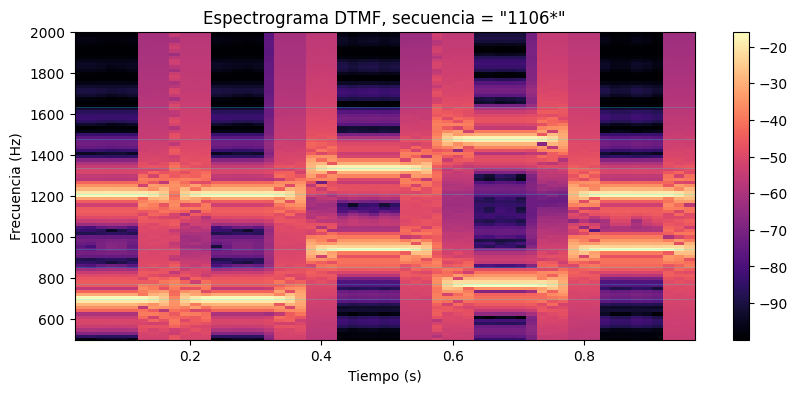

In [49]:
filas = {1: 697, 2: 770, 3: 852, 4: 941}
cols = {1: 1209, 2: 1336, 3: 1477, 4: 1633}
mapping = {
    (1,1):'1',(1,2):'2',(1,3):'3',(1,4):'A',
    (2,1):'4',(2,2):'5',(2,3):'6',(2,4):'B',
    (3,1):'7',(3,2):'8',(3,3):'9',(3,4):'C',
    (4,1):'*',(4,2):'0',(4,3):'#',(4,4):'D',
}

def dtmf_tone(key, dur=0.15, fs=8000):
    ### COMPLETAR ESTA FUNCIÓN
    for (i,j), k in mapping.items():
        if k == key:
            f_low = filas[i]
            f_high = cols[j]
            break
    n = np.arange(int(fs * dur))
    
    return np.cos(2*np.pi*f_low* n /fs) + np.cos(2*np.pi*f_high* n /fs)
    

    

secuencia = '1106*'   # código de ejemplo, reemplazar por número de teléfono deseado
fs = 8000
audio = np.concatenate([
    np.concatenate([dtmf_tone(k, fs=fs), np.zeros(int(0.05*fs))])
    for k in secuencia
])
display(Audio(audio, rate=fs))

# Decodificacion: STFT con ventanas largas para resolucion en frecuencia
f, t_stft, S = sig.spectrogram(audio, fs=fs, nperseg=512, noverlap=384) ### <-- COMPLETAR
plt.pcolormesh(t_stft, f, 10*np.log10(S+1e-10), shading='auto', cmap='magma')
plt.ylim(500, 2000)
for ff in list(filas.values())+list(cols.values()):
    plt.axhline(ff, color='cyan', alpha=0.3, lw=0.5)
plt.xlabel('Tiempo (s)'); plt.ylabel('Frecuencia (Hz)')
plt.title(f'Espectrograma DTMF, secuencia = "{secuencia}"')
plt.colorbar()
plt.show()

**Ejercicio para resolver.** Modificar la secuencia de arriba para algo más interesante
(por ejemplo, un número de teléfono) y verificar que los pares de tonos correspondientes
se identifican claramente en el espectrograma. La detección automática se haría midiendo
energía en las ocho frecuencias DTMF en cada ventana y comparando contra un umbral.

## Cierre

Esta práctica fija algunas herramientas que se usarán durante todo el curso:

- Lectura de un archivo de audio.
- STFT con $\texttt{scipy.signal.spectrogram}$.
- Ventaneo y compromiso resolución tiempo-frecuencia.
- Lectura de un espectrograma para identificar componentes frecuenciales.

En la próxima clase práctica vamos a aplicar lo mismo sobre habla real para poder leer fonemas en espectrogramas.